In [ ]:
import os
import gc

import torch
import torch.nn as nn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    Qwen2VLForConditionalGeneration,
    CLIPProcessor,
    CLIPModel,
)

from peft import (
    LoraConfig,
    get_peft_model,
    PeftModel,
)

from qwen_vl_utils import process_vision_info


In [ ]:

groups = {
    'SFW_Characters': [
        'Battu', 'Brian Griffin', 'Chota Bheem', 'Daffy Duck', 'Fred', 'Krishna', 
        'Looney tunes', 'Mickey Mouse', 'Minion', 'Mr. Bean', 'Oggy', 'Peter Griffin', 
        'Pink Panther', 'Simpson', 'SpongeBob', 'Squidward', 'Wild man', 'Winnie the Pooh'
    ],
    'NSFW_Content': [
        'AdultContents', 'Genitals', 'Nudity', 'nude', 'Sexual Position', 
        'Sexual innuendo', 'nsfw detection', 'Kiss', 'bikini'
    ],
    'Violence_Danger': ['Gun', 'pistol', 'Violent', 'Harassment', 'gross'],
    'Objects_Nature': ['airplane', 'car', 'clock', 'time', 'tree', 'umbrella', 'toy'],
    'Animals': ['elephant', 'panda', 'tiger', 'zebra'],
    'Humans': ['boy', 'person', 'player']
}

def compress_with_others(df):
    new_df = pd.DataFrame(index=df.index)
    new_df['filename'] = df['filename']
    
    for group_name, keywords in groups.items():
        matched_cols = [
            c for c in df.columns 
            if any(k.lower() in str(c).lower() for k in keywords)
        ]
        
        if matched_cols:
            new_df[group_name] = df[matched_cols].max(axis=1)
        else:
            new_df[group_name] = 0
            
    category_cols = list(groups.keys())
    new_df['Others'] = (new_df[category_cols].sum(axis=1) == 0).astype(int)
    
    return new_df

df=pd.read_csv("_classes_v.big.csv")
compressed_df = compress_with_others(df)

In [2]:
compressed_df.iloc[:,1:].value_counts()

SFW_Characters  NSFW_Content  Violence_Danger  Objects_Nature  Animals  Humans  Others
0               0             0                0               0        0       1         7769
                              1                0               0        0       0         5948
                1             0                0               0        0       0         2748
1               0             0                0               0        0       0         1393
0               0             0                1               0        0       0          204
                                               0               0        1       0          196
                1             1                0               0        0       0          134
                0             1                1               1        1       0           60
                                               0               1        1       0           27
                              0                1          

In [3]:
compressed_df

,filename,SFW_Characters,NSFW_Content,Violence_Danger,Objects_Nature,Animals,Humans,Others
0,photo_150690-05-05-2024_23-29-07_jpg.rf.e53972...,0,1,0,0,0,0,0
1,train3-1046-_jpg.rf.c317d6134df09fbf126cb927a1...,0,0,0,0,0,0,1
2,0000000400_jpg.rf.c61d42df2a25a92b55d8c2d4eb54...,0,0,1,0,0,0,0
3,Image_53_jpg.rf.71762d7cf1334bfc9b45ceb956160c...,0,0,0,0,0,0,1
4,31897922_jpg.rf.6d5794d568be68f08f605a633dcfdf...,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...
18500,8058677_jpg.rf.036db47f3d33157cf30c7d27278fad0...,0,0,0,0,0,0,1
18501,buttocks_9154699510480185836_jpeg.rf.8a5c486c1...,0,0,0,0,0,0,1
18502,107_jpg.rf.e04cedf22eac1e64f7073a634adae4dc.jpg,1,0,0,0,0,0,0
18503,pexels-photo-28961382_jpeg.rf.1b20a2b298fe19cd...,0,0,0,0,0,0,1


In [ ]:

model_id = "Qwen/Qwen2-VL-7B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, 
    quantization_config=bnb_config, 
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(
    model_id, 
    min_pixels=256 * 28 * 28, 
    max_pixels=512 * 28 * 28
)

def qwen_pipeline_with_checkpoint(df, img_folder="train/", limit=None, 
                                  checkpoint_path="safety_checkpoint.csv", 
                                  save_freq=1000):
    """
    Processes images for safety classification and generates descriptions using Qwen-VL.
    Automatically saves progress to a checkpoint file at specified intervals to prevent data loss.
    """
    
    # 1. Resume Logic
    if os.path.exists(checkpoint_path):
        print(f"Found existing checkpoint at {checkpoint_path}. Resuming process...")
        df_working = pd.read_csv(checkpoint_path, index_col=0)
    else:
        print("Starting a new classification process...")
        if limit:
            df_working = df.head(limit).copy()
        else:
            df_working = df.copy()
        
        for col in ['safety_category', 'safety_reason', 'clip_description']:
            if col not in df_working.columns: 
                df_working[col] = None

    print(f"Auto-save configured for every {save_freq} new images.")

    processed_count = 0
    
    for index, row in tqdm(df_working.iterrows(), total=len(df_working), desc="Processing"):
        
        # Smart Skip: bypass images that have already been classified
        if pd.notna(row['safety_category']):
            continue

        try:
            img_path = os.path.join(img_folder, str(row['filename']))
            
            prompt = """Analyze this image for two tasks:
            Task 1 (Safety): Classify for a Children's App into ONE: 
            [Safe_Child_Friendly, Cartoon_With_Innuendo, Revealing_Clothing, Explicit_Adult, Violence_Scary, Other].
            Task 2 (Description): Write a short, descriptive caption (max 15 words) describing the visual content for CLIP training.
            Format exactly like this:
            Category: [CATEGORY] | Reason: [REASON] | Desc: [DESCRIPTION]"""

            messages = [
                {
                    "role": "user", 
                    "content": [
                        {"type": "image", "image": img_path}, 
                        {"type": "text", "text": prompt}
                    ]
                }
            ]

            text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            image_inputs, _ = process_vision_info(messages)
            
            inputs = processor(
                text=[text], 
                images=image_inputs, 
                padding=True, 
                return_tensors="pt"
            ).to(device)

            generated_ids = model.generate(**inputs, max_new_tokens=80)
            output = processor.batch_decode(
                generated_ids[:, inputs.input_ids.shape[1]:], 
                skip_special_tokens=True
            )[0]
            
            # Output Parsing
            if "|" in output:
                try:
                    parts = output.split("|")
                    cat = parts[0].split("Category:")[1].strip()
                    reason = parts[1].split("Reason:")[1].strip()
                    desc = parts[2].split("Desc:")[1].strip()
                    
                    df_working.at[index, 'safety_category'] = cat
                    df_working.at[index, 'safety_reason'] = reason
                    df_working.at[index, 'clip_description'] = desc
                except IndexError:
                    df_working.at[index, 'safety_reason'] = output
            else:
                df_working.at[index, 'safety_reason'] = output

            # Memory Cleanup
            del inputs, generated_ids, image_inputs
            gc.collect()
            torch.cuda.empty_cache()
            
            # Checkpoint Saving
            processed_count += 1
            if processed_count % save_freq == 0:
                df_working.to_csv(checkpoint_path, index=True) 
                tqdm.write(f"Checkpoint saved at index {index}")

        except Exception as e:
            tqdm.write(f"Error processing {row['filename']}: {e}")
            torch.cuda.empty_cache()
    
    # Final save after loop completion
    df_working.to_csv(checkpoint_path, index=True)
    print("Process completed successfully. Final dataset saved.")
    return df_working

if __name__ == "__main__":
    # Example usage:
    # df_final_V3 = qwen_pipeline_with_checkpoint(compressed_df, limit=None, save_freq=100)
    pass

In [ ]:
df_final_v2 = pd.read_csv("safety_checkpoint.csv")

In [4]:
df_final_v2['safety_category'].value_counts()

safety_category
Explicit_Adult           6995
Safe_Child_Friendly      5917
Revealing_Clothing       4783
Cartoon_With_Innuendo     449
Other                     127
[Safe_Child_Friendly]      53
[Violence_Scary]           14
Violence_Scary              5
[Guns]                      2
Safety                      1
Firearms                    1
Name: count, dtype: int64

In [25]:
print( f'the number of mislabeled data is {len(df_final_v2[(df_final_v2['safety_category']=='Safe_Child_Friendly' ) & (df_final_v2['Violence_Danger']== 1)])} as a safe but its violence danger is 1')
print( f'the number of mislabeled data is {len(df_final_v2[(df_final_v2['safety_category']=='Safe_Child_Friendly' ) & (df_final_v2['NSFW_Content']== 1)])} as a safe but its NSFW danger is 1')
count = len(
    df_final_v2[
        (df_final_v2['safety_category'].isin(['Explicit_Adult', 'Revealing_Clothing','Cartoon_With_Innuendo'])) &
        (
            (df_final_v2['Violence_Danger'] == 1) |
            (df_final_v2['NSFW_Content'] == 1)
        )
    ]
)

print(f"the number of correct labeled data is {count}")

count_2=len(
        df_final_v2[
        (df_final_v2['safety_category'].isin(['Explicit_Adult', 'Revealing_Clothing','Cartoon_With_Innuendo'])) &
        (
            (df_final_v2['Others'] == 1) 
        )
    ]
)
print(f"the number of correct labeled data is {count_2}")

count_3=len(
        df_final_v2[
        (df_final_v2['safety_category'].isin(['Safe_Child_Friendly'])) &
        (
            (df_final_v2['Others'] == 1) 
        )
    ]
)
print(f"the number of correct labeled data is {count_2}")

the number of mislabeled data is 967 as a safe but its violence danger is 1
the number of mislabeled data is 59 as a safe but its NSFW danger is 1
the number of correct labeled data is 7657
the number of correct labeled data is 4445
the number of correct labeled data is 4445


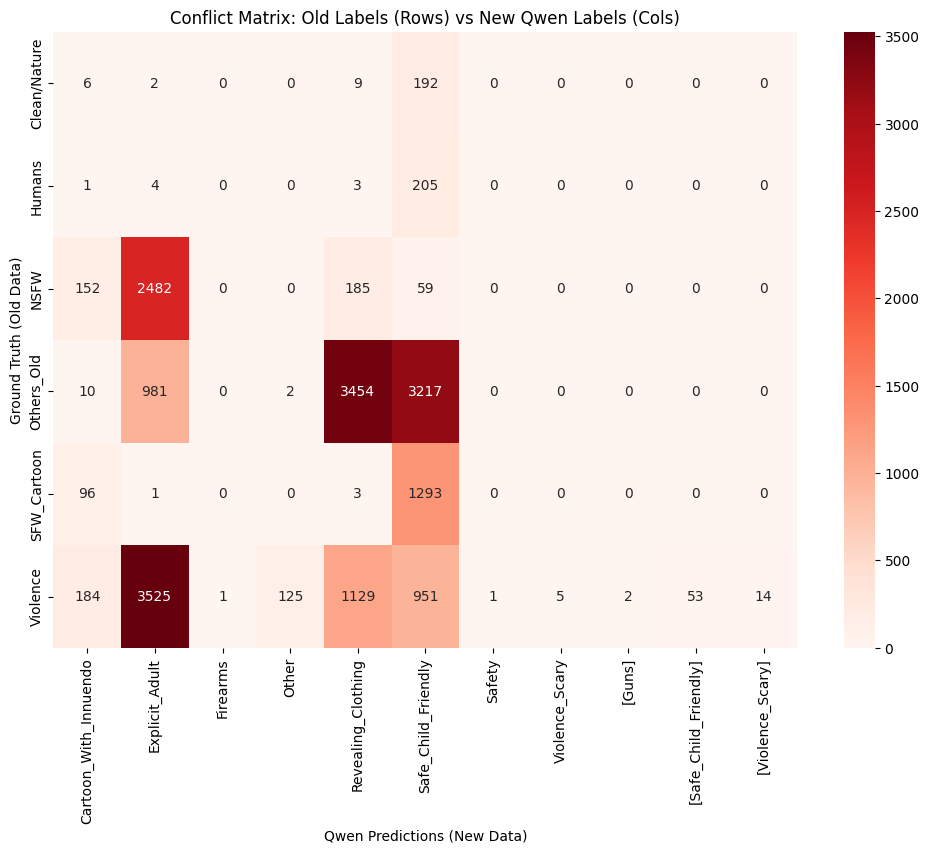

In [ ]:
def get_ground_truth(row):
    if row['NSFW_Content'] == 1: return 'NSFW'
    if row['Violence_Danger'] == 1: return 'Violence'
    if row['SFW_Characters'] == 1: return 'SFW_Cartoon'
    if row['Humans'] == 1: return 'Humans'
    if row['Others'] == 1: return 'Others_Old'
    return 'Clean/Nature'

df_final_v2['Old_Label'] = df_final_v2.apply(get_ground_truth, axis=1)

comparison_matrix = pd.crosstab(df_final_v2['Old_Label'], df_final_v2['safety_category'])

plt.figure(figsize=(12, 8))
sns.heatmap(comparison_matrix, annot=True, fmt='d', cmap='Reds')
plt.title('Conflict Matrix: Old Labels (Rows) vs New Qwen Labels (Cols)')
plt.ylabel('Ground Truth (Old Data)')
plt.xlabel('Qwen Predictions (New Data)')
plt.show()

In [ ]:
dangerous_miss = df_final_v2[
    (df_final_v2['Violence_Danger'] == 1) & 
    (df_final_v2['safety_category'].str.contains('Safe', case=False, na=False))
]

print(f"Number of dangerous miss: {len(dangerous_miss)}")
print(dangerous_miss[['filename', 'safety_reason']].head(10))

In [ ]:
trusted_df_cartoon=pd.read_csv('Cartoon-pornographic-Detection--33-1/_classes.csv')

trusted_df_cartoon['Violence_scary']=trusted_df_cartoon['Ann - v3 2024-10-02 5-02pm'].copy()
trusted_df_cartoon.drop(columns=['Ann - v3 2024-10-02 5-02pm'], inplace=True)
trusted_df_cartoon.head()


,filename,Genitals,Harassment,Kiss,Nudity,Sexual Position,Sexual innuendo,Violence_scary
0,IMG_0429_PNG_jpg.rf.c8c501e031db933d7f4c106962...,0,0,0,0,0,0,1
1,IMG_0324_PNG_jpg.rf.6cd8856fa373a7297a458969c3...,0,0,0,0,0,0,1
2,876_png.rf.417a5b5a499b30884bc73415063d66f6.jpg,0,0,1,1,1,0,0
3,IMG_0324_PNG_jpg.rf.3ccf10cfee22d87c80ab4fdf66...,0,0,0,0,0,0,1
4,877_png.rf.f0a88371837d2d19a12269c1ae5a6ec0.jpg,0,0,1,1,1,0,0


In [ ]:

device = "cuda" if torch.cuda.is_available() else "cpu"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

model_id = "Qwen/Qwen2-VL-7B-Instruct" 

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, 
    quantization_config=bnb_config, 
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(
    model_id, 
    min_pixels=256*28*28, 
    max_pixels=512*28*28
)

print("Model loaded successfully.")

def generate_golden_data_multilabel_checkpoint(df, img_folder="trusted_data/", limit=None, 
                                               checkpoint_path="golden_data_checkpoint.csv", 
                                               save_freq=50):
    """
    Reads multiple columns and forces the model to generate a combined description,
    with automatic progress saving.
    """
    
    # --- A. Resume Logic ---
    if os.path.exists(checkpoint_path):
        print(f"Found existing checkpoint: {checkpoint_path}. Resuming...")
        subset_df = pd.read_csv(checkpoint_path, index_col=0)
    else:
        print("Starting a new process...")
        subset_df = df.copy()
        if limit: subset_df = subset_df.head(limit)
        
        # Initialize new columns
        for col in ['safety_category', 'safety_reason', 'clip_description', 'detailed_risks']:
            if col not in subset_df.columns:
                subset_df[col] = None

    # Risk mapping dictionary
    risk_mapping = {
        'Genitals': 'Explicit_Adult',
        'Nudity': 'Explicit_Adult',
        'Sexual Position': 'Explicit_Adult',
        'Sexual innuendo': 'Cartoon_With_Innuendo',
        'Kiss': 'Cartoon_With_Innuendo',
        'Harassment': 'Explicit_Adult',
        'Violence_scary': 'Violence_Scary',
        'NSFW_Content': 'Explicit_Adult',
        'Violence_Danger': 'Violence_Scary',
        'Revealing_Clothing': 'Revealing_Clothing'
    }

    print(f"Auto-save configured for every {save_freq} images.")
    processed_count = 0 

    for index, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc="Creating Golden Data"):
        
        # --- B. Smart Skip ---
        if pd.notna(row['safety_category']):
            continue

        try:
            img_path = os.path.join(img_folder, str(row['filename']))
            
            # --- Aggregate Risks ---
            current_risks = []
            final_categories = set()
            
            for col, new_cat in risk_mapping.items():
                if col in row and row[col] == 1:
                    current_risks.append(col)
                    final_categories.add(new_cat)

            # --- Determine Main Category ---
            if 'Explicit_Adult' in final_categories:
                main_category = 'Explicit_Adult'
            elif 'Violence_Scary' in final_categories:
                main_category = 'Violence_Scary'
            elif 'Cartoon_With_Innuendo' in final_categories:
                main_category = 'Cartoon_With_Innuendo'
            elif 'Revealing_Clothing' in final_categories:
                main_category = 'Revealing_Clothing'
            else:
                main_category = 'Safe_Child_Friendly'

            risks_str = ", ".join(current_risks) if current_risks else "No detected risks"

            # --- Directed Prompt ---
            prompt = f"""This is a CONFIRMED image containing: [{risks_str}].
    Based on this, the Main Category is: '{main_category}'.

    Instruction:
    1. Ignore environmental/background details that are not directly relevant to the subjects or safety assessment (e.g., nature, sky, room decor, scenery).
    2. Focus strictly on the main subjects, their physical interactions, visible objects, and any peripheral items that contribute to understanding the scene.
    3. Explicitly identify and describe the confirmed elements: {risks_str}.
    4. Explicitly mention the presence or absence of:
    - Weapons
    - Aggressive physical contact or violence
    - Inappropriate or revealing attire
    5. Provide a neutral, factual, and context-aware description without speculation about intent, emotions, or events not visually observable.
    6. Explain clearly why the image belongs to the category '{main_category}', using only visible evidence from the image.
    7. Prioritize safety-relevant elements over general aesthetics or background details.

    Format:
    Reason: [Why the image fits '{main_category}', referencing visible evidence and confirmed elements] |
    Desc: [Concise visual description focused on subjects, interactions, objects, weapons, aggression, attire, and other safety-critical details]
    """
            messages = [{"role": "user", "content": [{"type": "image", "image": img_path}, {"type": "text", "text": prompt}]}]

            text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            image_inputs, _ = process_vision_info(messages)
            inputs = processor(text=[text], images=image_inputs, padding=True, return_tensors="pt").to(device)

            generated_ids = model.generate(**inputs, max_new_tokens=100)
            output = processor.batch_decode(generated_ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
            
            # Result Extraction
            if "|" in output:
                try:
                    parts = output.split("|")
                    reason = parts[0].split("Reason:")[1].strip()
                    desc = parts[1].split("Desc:")[1].strip()
                    
                    subset_df.at[index, 'safety_category'] = main_category
                    subset_df.at[index, 'safety_reason'] = reason
                    subset_df.at[index, 'clip_description'] = desc
                    subset_df.at[index, 'detailed_risks'] = risks_str
                except IndexError:
                    subset_df.at[index, 'safety_reason'] = output
            else:
                subset_df.at[index, 'safety_reason'] = output

            # --- C. Auto-Save ---
            processed_count += 1
            if processed_count % save_freq == 0:
                subset_df.to_csv(checkpoint_path)

            # Memory Cleanup
            del inputs, generated_ids, image_inputs
            gc.collect()
            torch.cuda.empty_cache()
            
        except Exception as e:
            tqdm.write(f"Error on {row['filename']}: {e}")
            torch.cuda.empty_cache()
            
    # Final Save
    subset_df.to_csv(checkpoint_path)
    print("Process completed and final dataset saved.")
    return subset_df

جاري إعداد الموديل على كارت الشاشة...


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


✅ تم تحميل الموديل بنجاح.


In [3]:
df_golden = generate_golden_data_multilabel_checkpoint(trusted_df_cartoon, img_folder="Cartoon-pornographic-Detection--33-1/", limit=len(trusted_df_cartoon))
print(df_golden.head())

🚀 بدء عملية جديدة...
سيتم الحفظ التلقائي كل 50 صورة.


Creating Golden Data:   0%|          | 0/2835 [00:00<?, ?it/s]

✅ تم الانتهاء وحفظ الملف النهائي.
                                            filename  Genitals  Harassment  \
0  IMG_0429_PNG_jpg.rf.c8c501e031db933d7f4c106962...         0           0   
1  IMG_0324_PNG_jpg.rf.6cd8856fa373a7297a458969c3...         0           0   
2    876_png.rf.417a5b5a499b30884bc73415063d66f6.jpg         0           0   
3  IMG_0324_PNG_jpg.rf.3ccf10cfee22d87c80ab4fdf66...         0           0   
4    877_png.rf.f0a88371837d2d19a12269c1ae5a6ec0.jpg         0           0   

   Kiss  Nudity  Sexual Position  Sexual innuendo  Violence_scary  \
0     0       0                0                0               1   
1     0       0                0                0               1   
2     1       1                1                0               0   
3     0       0                0                0               1   
4     1       1                1                0               0   

  safety_category                                      safety_reason  \
0  Violenc

In [ ]:
cartoon_data=pd.read_csv('golden_data_checkpoint.csv')
all_data=pd.read_csv('safety_checkpoint.csv')

In [5]:
cartoon_data.head()
cartoon_data['safety_category'].value_counts()

safety_category
Violence_Scary           1223
Explicit_Adult            911
Cartoon_With_Innuendo      10
Name: count, dtype: int64

In [6]:
all_data.head()

,Unnamed: 0,filename,SFW_Characters,NSFW_Content,Violence_Danger,Objects_Nature,Animals,Humans,Others,safety_category,safety_reason,clip_description
0,0,photo_150690-05-05-2024_23-29-07_jpg.rf.e53972...,0,1,0,0,0,0,0,Revealing_Clothing,The image shows a person wearing shorts that r...,A person wearing shorts with their legs visible.
1,1,train3-1046-_jpg.rf.c317d6134df09fbf126cb927a1...,0,0,0,0,0,0,1,Explicit_Adult,Adult Content,A woman with a tattoo on her back is engaged i...
2,2,0000000400_jpg.rf.c61d42df2a25a92b55d8c2d4eb54...,0,0,1,0,0,0,0,Revealing_Clothing,The individual is wearing casual clothing suit...,A person in a light-colored shirt and cap is h...
3,3,Image_53_jpg.rf.71762d7cf1334bfc9b45ceb956160c...,0,0,0,0,0,0,1,Revealing_Clothing,The image shows a person wearing tight-fitting...,A person wearing tight-fitting jeans with a ha...
4,4,31897922_jpg.rf.6d5794d568be68f08f605a633dcfdf...,0,0,0,0,0,0,1,Revealing_Clothing,The individual is wearing a revealing outfit.,A person in revealing clothing sits on a woode...


In [ ]:
import pandas as pd

cols = ['filename', 'safety_category', 'safety_reason', 'clip_description']

df_main = all_data[cols].copy()
df_golden = cartoon_data[cols].copy()

golden_filenames = df_golden['filename'].unique()

# Filter out duplicates
df_main_filtered = df_main[~df_main['filename'].isin(golden_filenames)]

final_dataset = pd.concat([df_main_filtered, df_golden], ignore_index=True)

print(f"Original row count: {len(df_main)}")
print(f"Golden data row count: {len(df_golden)}")
print(f"Row count after removing duplicates: {len(df_main_filtered)}")
print(f"Expected final count: {len(df_main_filtered) + len(df_golden)}")
print(f"Actual final count: {len(final_dataset)}")

duplicates = final_dataset['filename'].duplicated().sum()
print(f"Duplicate files in final dataset: {duplicates} (Expected: 0)")

print(final_dataset.head())

In [10]:
final_dataset.to_csv('final.csv', index=False)

In [13]:
final_dataset.safety_category.value_counts()

safety_category
Explicit_Adult           7906
Safe_Child_Friendly      5917
Revealing_Clothing       4783
Violence_Scary           1228
Cartoon_With_Innuendo     459
Other                     127
[Safe_Child_Friendly]      53
[Violence_Scary]           14
[Guns]                      2
Safety                      1
Firearms                    1
Name: count, dtype: int64

In [ ]:
def clean_and_merge_taxonomy(df):
    df_clean = df.copy()
    
    # Mapping Dictionary for label harmonization
    taxonomy_map = {
        # Violence harmonization
        'Violence_Scary': 'Violence_Scary',
        '[Violence_Scary]': 'Violence_Scary',
        '[Guns]': 'Violence_Scary',
        'Firearms': 'Violence_Scary',
        'Safety': 'Violence_Scary', 
        
        # Safe harmonization
        'Safe_Child_Friendly': 'Safe_Child_Friendly',
        '[Safe_Child_Friendly]': 'Safe_Child_Friendly',
        
        # Base categories
        'Explicit_Adult': 'Explicit_Adult',
        'Revealing_Clothing': 'Revealing_Clothing',
        'Cartoon_With_Innuendo': 'Cartoon_With_Innuendo',
        'Other': 'Other'
    }
    
    df_clean['safety_category'] = df_clean['safety_category'].map(taxonomy_map).fillna('Other')
    return df_clean

# Assuming 'final_dataset' is available from the previous step
final_clean_df = clean_and_merge_taxonomy(final_dataset) 

print(final_clean_df['safety_category'].value_counts())

safety_category
Explicit_Adult           7906
Safe_Child_Friendly      5970
Revealing_Clothing       4783
Violence_Scary           1246
Other                     976
Cartoon_With_Innuendo     459
Name: count, dtype: int64


In [15]:
final_clean_df.to_csv('final_clean.csv', index=False)

In [16]:
final_clean_df.head()

,filename,safety_category,safety_reason,clip_description
0,photo_150690-05-05-2024_23-29-07_jpg.rf.e53972...,Revealing_Clothing,The image shows a person wearing shorts that r...,A person wearing shorts with their legs visible.
1,train3-1046-_jpg.rf.c317d6134df09fbf126cb927a1...,Explicit_Adult,Adult Content,A woman with a tattoo on her back is engaged i...
2,0000000400_jpg.rf.c61d42df2a25a92b55d8c2d4eb54...,Revealing_Clothing,The individual is wearing casual clothing suit...,A person in a light-colored shirt and cap is h...
3,Image_53_jpg.rf.71762d7cf1334bfc9b45ceb956160c...,Revealing_Clothing,The image shows a person wearing tight-fitting...,A person wearing tight-fitting jeans with a ha...
4,31897922_jpg.rf.6d5794d568be68f08f605a633dcfdf...,Revealing_Clothing,The individual is wearing a revealing outfit.,A person in revealing clothing sits on a woode...


In [ ]:
final_clean_df = pd.read_csv('final_clean.csv')

In [ ]:
def clean_and_merge_taxonomy(df):
    df_clean = df.copy()
    
    # Mapping Dictionary for label harmonization
    taxonomy_map = {
        # Violence harmonization
        'Violence_Scary': 'Violence_Scary',
        '[Violence_Scary]': 'Violence_Scary',
        '[Guns]': 'Violence_Scary',
        'Firearms': 'Violence_Scary',
        'Safety': 'Violence_Scary', 
        
        # Safe harmonization
        'Safe_Child_Friendly': 'Safe_Child_Friendly',
        '[Safe_Child_Friendly]': 'Safe_Child_Friendly',
        
        # Base categories
        'Explicit_Adult': 'Explicit_Adult',
        'Revealing_Clothing': 'Revealing_Clothing',
        'Cartoon_With_Innuendo': 'Cartoon_With_Innuendo',
        'Other': 'Other'
    }
    
    df_clean['safety_category'] = df_clean['safety_category'].map(taxonomy_map).fillna('Other')
    return df_clean

# Assuming 'final_dataset' is available from the previous step
final_clean_df = clean_and_merge_taxonomy(final_dataset) 

print(final_clean_df['safety_category'].value_counts())

🔄 Loading Binary Model from clip_binary_stage_1...
✅ Model loaded successfully!
📊 Testing on 200 balanced images (100 Safe, 100 Unsafe).
🚀 Running Inference on 200 images...


  0%|          | 0/200 [00:00<?, ?it/s]


🎯 Binary Classification Accuracy: 50.00%

⚠️ Error Analysis:
- False Positives (Safe classified as Unsafe): 48
- False Negatives (Unsafe classified as Safe): 52

🔎 Sample Failures:
     Original Category       Predicted Confidence
0       Violence_Scary    Safe_Content      56.4%
2  Safe_Child_Friendly  Unsafe_Content      50.1%
3  Safe_Child_Friendly  Unsafe_Content      52.3%
6  Safe_Child_Friendly  Unsafe_Content      50.5%
7   Revealing_Clothing    Safe_Content      51.6%


In [ ]:
model_id = "openai/clip-vit-base-patch32"
BATCH_SIZE = 32
EPOCHS = 3 
LEARNING_RATE = 1e-4
device = "cuda" if torch.cuda.is_available() else "cpu"

class RichTextCLIPDataset(Dataset):
    def __init__(self, df, processor, img_folder="train/"):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.img_folder = img_folder

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.img_folder, str(row['filename']))
        
        category_prefix = "Safe" if row['safety_category'] in ['Safe_Child_Friendly', 'Safe'] else "Unsafe"
        text = f"{category_prefix}: {row['clip_description']}"
        
        try:
            image = Image.open(image_path).convert("RGB")
        except Exception:
            image = Image.new('RGB', (224, 224), color='black')

        inputs = self.processor(
            text=[text],
            images=image,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=77
        )

        return {
            "input_ids": inputs['input_ids'].squeeze(0),
            "attention_mask": inputs['attention_mask'].squeeze(0),
            "pixel_values": inputs['pixel_values'].squeeze(0)
        }

def train_clip_final(dataframe):
    model = CLIPModel.from_pretrained(model_id)
    processor = CLIPProcessor.from_pretrained(model_id)
    
    config = LoraConfig(
        r=16, 
        lora_alpha=32, 
        target_modules=["q_proj", "v_proj"], 
        lora_dropout=0.05,
        bias="none"
    )
    model = get_peft_model(model, config)
    model.to(device)
    model.train()
    
    dataset = RichTextCLIPDataset(dataframe, processor)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    loss_img = nn.CrossEntropyLoss()
    loss_txt = nn.CrossEntropyLoss()

    print(f"Starting CLIP Training on {len(dataframe)} images...")

    for epoch in range(EPOCHS):
        total_loss = 0
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        
        for batch in progress_bar:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            
            optimizer.zero_grad()
            
            outputs = model(
                input_ids=input_ids, 
                attention_mask=attention_mask, 
                pixel_values=pixel_values,
                return_loss=True
            )
            
            labels = torch.arange(len(input_ids)).to(device)
            loss = (loss_img(outputs.logits_per_image, labels) + loss_txt(outputs.logits_per_text, labels)) / 2
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            progress_bar.set_postfix({"loss": loss.item()})
            
        print(f"Epoch {epoch+1} Avg Loss: {total_loss / len(dataloader):.4f}")
        
    model.save_pretrained("clip_finetuned_final")
    return model, processor

trained_model, proc = train_clip_final(final_clean_df)

🚀 Starting CLIP Training on 21340 images...


Epoch 1/3:   0%|          | 0/667 [00:00<?, ?it/s]

Epoch 1 Avg Loss: 0.2829


Epoch 2/3:   0%|          | 0/667 [00:00<?, ?it/s]

Epoch 2 Avg Loss: 0.1750


Epoch 3/3:   0%|          | 0/667 [00:00<?, ?it/s]

Epoch 3 Avg Loss: 0.1408


In [ ]:
ADAPTER_PATH = "clip_finetuned_final" 
IMG_FOLDER = "train/" 

CANDIDATE_LABELS = [
    "Safe: Safe, innocent, child-friendly content.",
    "Unsafe: Unsafe content containing violence, adult themes, or revealing clothing."
]

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading CLIP Model from {ADAPTER_PATH}...")
try:
    base_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    
    model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
    model = model.merge_and_unload() 
    model.to(device)
    model.eval()
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    raise e 

def get_true_label_text(cat):
    if cat in ['Safe_Child_Friendly', 'Safe', 'Safe_Content']:
        return CANDIDATE_LABELS[0]
    return CANDIDATE_LABELS[1]

def prepare_test_sample(df, sample_size=200):
    df_test = df.copy()
    df_test['is_safe'] = df_test['safety_category'].isin(['Safe_Child_Friendly', 'Safe', 'Safe_Content'])
    
    safe_samples = df_test[df_test['is_safe'] == True]
    unsafe_samples = df_test[df_test['is_safe'] == False]
    
    n_samples = min(len(safe_samples), len(unsafe_samples), sample_size // 2)
    
    if n_samples == 0:
        print("Warning: Insufficient data for balanced sampling.")
        return df_test.sample(min(len(df_test), sample_size))

    sampled_df = pd.concat([
        safe_samples.sample(n_samples),
        unsafe_samples.sample(n_samples)
    ]).sample(frac=1).reset_index(drop=True) 
    
    print(f"Testing on {len(sampled_df)} images ({n_samples} Safe vs {n_samples} Unsafe).")
    return sampled_df

def run_final_test(df):
    test_df = prepare_test_sample(df)
    results = []
    correct_count = 0
    
    print("Running Inference...")
    
    for index, row in tqdm(test_df.iterrows(), total=len(test_df)):
        img_path = os.path.join(IMG_FOLDER, str(row['filename']))
        true_text_label = get_true_label_text(row['safety_category'])
        
        try:
            image = Image.open(img_path).convert("RGB")
            inputs = processor(text=CANDIDATE_LABELS, images=image, return_tensors="pt", padding=True).to(device)
            
            with torch.no_grad():
                outputs = model(**inputs)
            
            probs = outputs.logits_per_image.softmax(dim=1).squeeze()
            top_prob, top_idx = probs.topk(1)
            
            predicted_text = CANDIDATE_LABELS[top_idx.item()]
            confidence = top_prob.item() * 100
            
            is_correct = (predicted_text == true_text_label)
            if is_correct: 
                correct_count += 1
            
            short_pred = predicted_text.split(":")[0]
            short_true = true_text_label.split(":")[0]
            
            results.append({
                "Filename": row['filename'],
                "Original": row['safety_category'],
                "True": short_true,
                "Pred": short_pred,
                "Conf": f"{confidence:.1f}%",
                "Status": "Pass" if is_correct else "Fail"
            })
            
        except Exception:
            pass 

    if len(results) == 0:
        print("Error: No images processed successfully.")
        return

    results_df = pd.DataFrame(results)
    accuracy = (correct_count / len(results_df)) * 100
    
    print("\n" + "="*40)
    print(f"CLIP Accuracy (Rich Text Strategy): {accuracy:.2f}%")
    print("="*40)
    
    if accuracy < 100:
        fails = results_df[results_df['Status'] == "Fail"]
        safe_fp = len(fails[fails['True'] == 'Safe'])
        unsafe_fn = len(fails[fails['True'] == 'Unsafe'])
        
        print("\nError Analysis:")
        print(f"- Safe labeled as Unsafe (False Positive): {safe_fp}")
        print(f"- Unsafe labeled as Safe (False Negative): {unsafe_fn}")
        return fails[fails['True'] == 'Unsafe']
    else:
        print("\nPerfect Score!")

🔄 Loading CLIP Model from clip_finetuned_final...
✅ Model loaded successfully!


In [ ]:
t=run_final_test(final_clean_df[(final_clean_df['safety_category']=='Revealing_Clothing')|(final_clean_df['safety_category']=='Safe_Child_Friendly')])

📊 Testing on 200 images (100 Safe vs 100 Unsafe).
🚀 Running Inference...


  0%|          | 0/200 [00:00<?, ?it/s]


🎯 CLIP Accuracy (Rich Text Strategy): 74.50%

⚠️ Error Analysis:
- Safe labeled as Unsafe (False Positive): 42
- Unsafe labeled as Safe (False Negative): 9


In [ ]:
df_final_v2= pd.read_csv("old_csv/df_final_v2.csv")
df_final_v2[df_final_v2['Violence_Danger']==1].category.value_counts()

category
Objects_Nature                                                   3509
Humans                                                           1190
NSFW_Content                                                      674
Normal Cartoon Characters                                         344
SFW_Characters                                                    305
Violence_Danger                                                    70
Animals                                                            40
Other                                                              38
The image is labeled as "NSFW_Content" and "Violence_Danger".       1
NSFW_Content, Violence_Danger                                       1
Name: count, dtype: int64

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

model_id = "Qwen/Qwen2-VL-7B-Instruct" 

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, 
    quantization_config=bnb_config, 
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(
    model_id, 
    min_pixels=256*28*28, 
    max_pixels=512*28*28
)

print("Model loaded successfully.")

def generate_golden_data_multilabel_checkpoint(df, img_folder="train/", limit=None, 
                                               checkpoint_path="golden_data_checkpoint.csv", 
                                               save_freq=50):
    
    if os.path.exists(checkpoint_path):
        print(f"Found existing checkpoint: {checkpoint_path}. Resuming...")
        subset_df = pd.read_csv(checkpoint_path, index_col=0)
    else:
        print("Starting a new process...")
        subset_df = df.copy()
        if limit: subset_df = subset_df.head(limit)
        
        for col in ['safety_category', 'safety_reason', 'clip_description', 'detailed_risks']:
            if col not in subset_df.columns:
                subset_df[col] = None

    risk_mapping = {
        'Violence_Danger': 'Violence_Scary',
    }

    processed_count = 0 

    for index, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc="Creating Golden Data"):
        if pd.notna(row['safety_category']):
            continue

        try:
            img_path = os.path.join(img_folder, str(row['filename']))
            
            current_risks = []
            final_categories = set()
            
            for col, new_cat in risk_mapping.items():
                if col in row and row[col] == 1:
                    current_risks.append(col)
                    final_categories.add(new_cat)

            if 'Explicit_Adult' in final_categories:
                main_category = 'Explicit_Adult'
            elif 'Violence_Scary' in final_categories:
                main_category = 'Violence_Scary'
            elif 'Cartoon_With_Innuendo' in final_categories:
                main_category = 'Cartoon_With_Innuendo'
            elif 'Revealing_Clothing' in final_categories:
                main_category = 'Revealing_Clothing'
            else:
                main_category = 'Safe_Child_Friendly'

            risks_str = ", ".join(current_risks) if current_risks else "No detected risks"

            prompt = f"""This is a CONFIRMED image containing: [{risks_str}].
            Based on this, the Main Category is: '{main_category}'.

            Instruction:
            1. Ignore environmental/background details that are not directly relevant to the subjects or safety assessment (e.g., nature, sky, room decor, scenery).
            2. Focus strictly on the main subjects, their physical interactions, visible objects, and any peripheral items that contribute to understanding the scene.
            3. Explicitly identify and describe the confirmed elements: {risks_str}.
            4. Explicitly mention the presence or absence of:
            - Weapons
            - Aggressive physical contact or violence
            - Inappropriate or revealing attire
            5. Provide a neutral, factual, and context-aware description without speculation about intent, emotions, or events not visually observable.
            6. Explain clearly why the image belongs to the category '{main_category}', using only visible evidence from the image.
            7. Prioritize safety-relevant elements over general aesthetics or background details.

            Format:
            Reason: [Why the image fits '{main_category}', referencing visible evidence and confirmed elements] |
            Desc: [Concise visual description focused on subjects, interactions, objects, weapons, aggression, attire, and other safety-critical details]
            """

            messages = [{"role": "user", "content": [{"type": "image", "image": img_path}, {"type": "text", "text": prompt}]}]

            text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            image_inputs, _ = process_vision_info(messages)
            inputs = processor(text=[text], images=image_inputs, padding=True, return_tensors="pt").to(device)

            generated_ids = model.generate(**inputs, max_new_tokens=100)
            output = processor.batch_decode(generated_ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
            
            if "|" in output:
                try:
                    parts = output.split("|")
                    reason = parts[0].split("Reason:")[1].strip()
                    desc = parts[1].split("Desc:")[1].strip()
                    
                    subset_df.at[index, 'safety_category'] = main_category
                    subset_df.at[index, 'safety_reason'] = reason
                    subset_df.at[index, 'clip_description'] = desc
                    subset_df.at[index, 'detailed_risks'] = risks_str
                except IndexError:
                    subset_df.at[index, 'safety_reason'] = output
            else:
                subset_df.at[index, 'safety_reason'] = output

            processed_count += 1
            if processed_count % save_freq == 0:
                subset_df.to_csv(checkpoint_path)

            del inputs, generated_ids, image_inputs
            gc.collect()
            torch.cuda.empty_cache()
            
        except Exception as e:
            tqdm.write(f"Error on {row['filename']}: {e}")
            torch.cuda.empty_cache()
            
    subset_df.to_csv(checkpoint_path)
    print("Process completed and final dataset saved.")
    return subset_df

جاري إعداد الموديل على كارت الشاشة...


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


✅ تم تحميل الموديل بنجاح.


In [5]:
Violance_data=df_final_v2[df_final_v2['Violence_Danger']==1][['filename','Violence_Danger']]
Violance_data

,filename,Violence_Danger
2,0000000400_jpg.rf.c61d42df2a25a92b55d8c2d4eb54...,1
5,armas-2383-_jpg.rf.2e8d034edd41e77e11e5d278985...,1
6,0000001957_jpg.rf.d945a9aeb95e7a2f7d6f78622fd9...,1
10,armas-2691-_jpg.rf.e24cfe0849bd5f6c2a56f7f3f41...,1
16,armas-2130-_jpg.rf.9be596e7bb99d1e3d6945e0478d...,1
...,...,...
18483,0000001732_jpg.rf.3fbf0cf09c164fca05fadf1a07ff...,1
18484,0000002996_jpg.rf.28099ba3d4dbdd3cbe6acc69ca3c...,1
18488,armas-2228-_jpg.rf.7d236e1de0c7353d666a573b004...,1
18491,0000000538_jpg.rf.c7869fa0a1c8e1602d7fd989df91...,1


In [8]:
generate_golden_data_multilabel_checkpoint(df=Violance_data, checkpoint_path='checkpoint_path_2.csv', save_freq=100, limit=len(),img_folder='train/')

🚀 بدء عملية جديدة...
سيتم الحفظ التلقائي كل 100 صورة.


Creating Golden Data:   0%|          | 0/6172 [00:00<?, ?it/s]

✅ تم الانتهاء وحفظ الملف النهائي.


,filename,Violence_Danger,safety_category,safety_reason,clip_description,detailed_risks
2,0000000400_jpg.rf.c61d42df2a25a92b55d8c2d4eb54...,1,Violence_Scary,"The image depicts a person holding a firearm, ...","A person is seen from behind, holding a handgu...",Violence_Danger
5,armas-2383-_jpg.rf.2e8d034edd41e77e11e5d278985...,1,Violence_Scary,"The image contains a firearm, which is a weapo...",The image shows a handgun with a wooden grip a...,Violence_Danger
6,0000001957_jpg.rf.d945a9aeb95e7a2f7d6f78622fd9...,1,Violence_Scary,"The image contains a firearm, which is a tool ...",The image shows a black handgun with the words...,Violence_Danger
10,armas-2691-_jpg.rf.e24cfe0849bd5f6c2a56f7f3f41...,1,Violence_Scary,"The image contains a firearm, specifically a r...",The image shows a metallic revolver with a woo...,Violence_Danger
16,armas-2130-_jpg.rf.9be596e7bb99d1e3d6945e0478d...,1,Violence_Scary,"The image contains a firearm, which is a tool ...",The image shows a black handgun with a texture...,Violence_Danger
...,...,...,...,...,...,...
18483,0000001732_jpg.rf.3fbf0cf09c164fca05fadf1a07ff...,1,Violence_Scary,"The image contains a firearm, which is a poten...",The image shows a hand holding a Sig Sauer P22...,Violence_Danger
18484,0000002996_jpg.rf.28099ba3d4dbdd3cbe6acc69ca3c...,1,Violence_Scary,The presence of a firearm and the act of aimin...,"A person is holding a rifle with a scope, stan...",Violence_Danger
18488,armas-2228-_jpg.rf.7d236e1de0c7353d666a573b004...,1,Violence_Scary,"The image contains a firearm, which is a tool ...",The image shows a black revolver with a wooden...,Violence_Danger
18491,0000000538_jpg.rf.c7869fa0a1c8e1602d7fd989df91...,1,Violence_Scary,"The image contains a firearm, which is a symbo...",The image shows a black handgun with a red and...,Violence_Danger


In [ ]:
df=pd.read_csv('checkpoint_path_2.csv')
df.head()

,Unnamed: 0,filename,Violence_Danger,safety_category,safety_reason,clip_description,detailed_risks
0,2,0000000400_jpg.rf.c61d42df2a25a92b55d8c2d4eb54...,1,Violence_Scary,"The image depicts a person holding a firearm, ...","A person is seen from behind, holding a handgu...",Violence_Danger
1,5,armas-2383-_jpg.rf.2e8d034edd41e77e11e5d278985...,1,Violence_Scary,"The image contains a firearm, which is a weapo...",The image shows a handgun with a wooden grip a...,Violence_Danger
2,6,0000001957_jpg.rf.d945a9aeb95e7a2f7d6f78622fd9...,1,Violence_Scary,"The image contains a firearm, which is a tool ...",The image shows a black handgun with the words...,Violence_Danger
3,10,armas-2691-_jpg.rf.e24cfe0849bd5f6c2a56f7f3f41...,1,Violence_Scary,"The image contains a firearm, specifically a r...",The image shows a metallic revolver with a woo...,Violence_Danger
4,16,armas-2130-_jpg.rf.9be596e7bb99d1e3d6945e0478d...,1,Violence_Scary,"The image contains a firearm, which is a tool ...",The image shows a black handgun with a texture...,Violence_Danger


In [ ]:
df[['filename','detailed_risks']]


detailed_risks
Violence_Danger    5934
Name: count, dtype: int64

In [4]:
final_clean_df=pd.read_csv('final_clean.csv')    
final_clean_df.head()

,filename,safety_category,safety_reason,clip_description
0,photo_150690-05-05-2024_23-29-07_jpg.rf.e53972...,Revealing_Clothing,The image shows a person wearing shorts that r...,A person wearing shorts with their legs visible.
1,train3-1046-_jpg.rf.c317d6134df09fbf126cb927a1...,Explicit_Adult,Adult Content,A woman with a tattoo on her back is engaged i...
2,0000000400_jpg.rf.c61d42df2a25a92b55d8c2d4eb54...,Revealing_Clothing,The individual is wearing casual clothing suit...,A person in a light-colored shirt and cap is h...
3,Image_53_jpg.rf.71762d7cf1334bfc9b45ceb956160c...,Revealing_Clothing,The image shows a person wearing tight-fitting...,A person wearing tight-fitting jeans with a ha...
4,31897922_jpg.rf.6d5794d568be68f08f605a633dcfdf...,Revealing_Clothing,The individual is wearing a revealing outfit.,A person in revealing clothing sits on a woode...


In [ ]:

cols = ['filename', 'safety_category', 'safety_reason', 'clip_description']

df_main = final_clean_df[cols].copy()
df_golden = df[cols].copy()

golden_filenames = df_golden['filename'].unique()

df_main_filtered = df_main[~df_main['filename'].isin(golden_filenames)]
final_dataset = pd.concat([df_main_filtered, df_golden], ignore_index=True)

print(f"Original main dataset count: {len(df_main)}")
print(f"Golden dataset count: {len(df_golden)}")
print(f"Filtered main dataset count: {len(df_main_filtered)}")
print(f"Final dataset actual count: {len(final_dataset)}")

duplicates = final_dataset['filename'].duplicated().sum()
print(f"Duplicate filenames in final dataset: {duplicates} (Expected: 0)")

عدد الصفوف الأصلي: 21340
عدد صفوف الكارتون (الذهبية): 6172
عدد الصفوف بعد الحذف (القديمة - المكرر): 15168
العدد النهائي المتوقع: 21340
العدد النهائي الفعلي: 21340
عدد الملفات المكررة في الداتا النهائية: 0 (يجب أن يكون 0)
                                            filename      safety_category  \
0  photo_150690-05-05-2024_23-29-07_jpg.rf.e53972...   Revealing_Clothing   
1  train3-1046-_jpg.rf.c317d6134df09fbf126cb927a1...       Explicit_Adult   
2  Image_53_jpg.rf.71762d7cf1334bfc9b45ceb956160c...   Revealing_Clothing   
3  31897922_jpg.rf.6d5794d568be68f08f605a633dcfdf...   Revealing_Clothing   
4  87665_mp4-0014_jpg.rf.7d3440fec72f53c6688fb3d7...  Safe_Child_Friendly   

                                       safety_reason  \
0  The image shows a person wearing shorts that r...   
1                                      Adult Content   
2  The image shows a person wearing tight-fitting...   
3      The individual is wearing a revealing outfit.   
4                                No 

In [7]:
final_dataset['safety_category'].value_counts()

safety_category
Violence_Scary           7157
Safe_Child_Friendly      4950
Explicit_Adult           4331
Revealing_Clothing       3650
Other                     803
Cartoon_With_Innuendo     211
Name: count, dtype: int64

In [9]:
final_dataset.to_csv('final_clean_V2.csv', index=False)

In [ ]:
final_clean_df=pd.read_csv('final_clean_V2.csv')    
final_clean_df.head()

,filename,safety_category,safety_reason,clip_description
0,photo_150690-05-05-2024_23-29-07_jpg.rf.e53972...,Revealing_Clothing,The image shows a person wearing shorts that r...,A person wearing shorts with their legs visible.
1,train3-1046-_jpg.rf.c317d6134df09fbf126cb927a1...,Explicit_Adult,Adult Content,A woman with a tattoo on her back is engaged i...
2,Image_53_jpg.rf.71762d7cf1334bfc9b45ceb956160c...,Revealing_Clothing,The image shows a person wearing tight-fitting...,A person wearing tight-fitting jeans with a ha...
3,31897922_jpg.rf.6d5794d568be68f08f605a633dcfdf...,Revealing_Clothing,The individual is wearing a revealing outfit.,A person in revealing clothing sits on a woode...
4,87665_mp4-0014_jpg.rf.7d3440fec72f53c6688fb3d7...,Safe_Child_Friendly,No explicit content,A cartoon dog and cat interact with a woman on...


In [ ]:
trained_model, proc = train_clip_final(final_clean_df)# on cell [12]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


🚀 Starting CLIP Training on 21340 images...


Epoch 1/3:   0%|          | 0/667 [00:00<?, ?it/s]

Epoch 1 Avg Loss: 0.2977


Epoch 2/3:   0%|          | 0/667 [00:00<?, ?it/s]

Epoch 2 Avg Loss: 0.1906


Epoch 3/3:   0%|          | 0/667 [00:00<?, ?it/s]

Epoch 3 Avg Loss: 0.1525


In [ ]:
final_clean_df=pd.read_csv("final_clean_V2.csv")

In [17]:
final_clean_df

,filename,safety_category,safety_reason,clip_description
0,photo_150690-05-05-2024_23-29-07_jpg.rf.e53972...,Revealing_Clothing,The image shows a person wearing shorts that r...,A person wearing shorts with their legs visible.
1,train3-1046-_jpg.rf.c317d6134df09fbf126cb927a1...,Explicit_Adult,Adult Content,A woman with a tattoo on her back is engaged i...
2,Image_53_jpg.rf.71762d7cf1334bfc9b45ceb956160c...,Revealing_Clothing,The image shows a person wearing tight-fitting...,A person wearing tight-fitting jeans with a ha...
3,31897922_jpg.rf.6d5794d568be68f08f605a633dcfdf...,Revealing_Clothing,The individual is wearing a revealing outfit.,A person in revealing clothing sits on a woode...
4,87665_mp4-0014_jpg.rf.7d3440fec72f53c6688fb3d7...,Safe_Child_Friendly,No explicit content,A cartoon dog and cat interact with a woman on...
...,...,...,...,...
21335,0000001732_jpg.rf.3fbf0cf09c164fca05fadf1a07ff...,Violence_Scary,"The image contains a firearm, which is a poten...",The image shows a hand holding a Sig Sauer P22...
21336,0000002996_jpg.rf.28099ba3d4dbdd3cbe6acc69ca3c...,Violence_Scary,The presence of a firearm and the act of aimin...,"A person is holding a rifle with a scope, stan..."
21337,armas-2228-_jpg.rf.7d236e1de0c7353d666a573b004...,Violence_Scary,"The image contains a firearm, which is a tool ...",The image shows a black revolver with a wooden...
21338,0000000538_jpg.rf.c7869fa0a1c8e1602d7fd989df91...,Violence_Scary,"The image contains a firearm, which is a symbo...",The image shows a black handgun with a red and...


In [12]:
t=run_final_test(final_clean_df[final_clean_df['safety_category']!='Violence_Scary'],100)
# t=run_final_test(final_clean_df,100)

📊 Testing on 100 images (50 Safe vs 50 Unsafe).
🚀 Running Inference...


  0%|          | 0/100 [00:00<?, ?it/s]


🎯 CLIP Accuracy (Rich Text Strategy): 75.00%

⚠️ Error Analysis:
- Safe labeled as Unsafe (False Positive): 4
- Unsafe labeled as Safe (False Negative): 21


In [13]:
t

,Filename,Original,True,Pred,Conf,Status
1,1_mp4-0005_jpg.rf.011c4408f2b68ef832ee4e241705...,Explicit_Adult,Unsafe,Safe,69.5%,❌
3,29092426_jpg.rf.d7ace54292116bbbccc8b1aa87b90e...,Explicit_Adult,Unsafe,Safe,59.8%,❌
8,null_8183793853763055152_jpeg.rf.0de375e65506f...,Revealing_Clothing,Unsafe,Safe,67.2%,❌
9,pexels-photo-8975641_jpeg.rf.ac9c52631b8127242...,Explicit_Adult,Unsafe,Safe,65.1%,❌
11,9410476_jpg.rf.853030aed2a936055a6a55d63423140...,Revealing_Clothing,Unsafe,Safe,72.9%,❌
12,buttocks_-9097054779276568716_jpeg.rf.38863a48...,Revealing_Clothing,Unsafe,Safe,74.3%,❌
23,pexels-photo-8156192_jpeg.rf.c3d5eec92be15b3b3...,Revealing_Clothing,Unsafe,Safe,55.7%,❌
33,pexels-photo-9623715_jpeg.rf.583e0dfc7a89d7246...,Revealing_Clothing,Unsafe,Safe,90.6%,❌
39,pexels-photo-10559295_jpeg.rf.b82e2bbc6db47c08...,Revealing_Clothing,Unsafe,Safe,74.9%,❌
41,breast_2362988983420330621_png.rf.c969291e3c77...,Revealing_Clothing,Unsafe,Safe,66.2%,❌


In [51]:
t[t['Original']=='Cartoon_With_Innuendo']

,Filename,Original,True,Pred,Conf,Status
299,2712_jpg.rf.ff719faa162a0b82e396f6fb603c0519.jpg,Cartoon_With_Innuendo,Unsafe,Safe,99.9%,❌
340,IMG_3469_MP4-0056_jpg.rf.d4525781fb9048d9ca3c3...,Cartoon_With_Innuendo,Unsafe,Safe,87.2%,❌
354,869_png.rf.b30e2b28dd1d4019f3c8e178efbe9508.jpg,Cartoon_With_Innuendo,Unsafe,Safe,95.1%,❌
374,1024_jpg.rf.37104645f23a46f4a1bfa01d52e61017.jpg,Cartoon_With_Innuendo,Unsafe,Safe,94.1%,❌
443,2711_jpg.rf.57e9bbccd93925454b18c4e9d091ceef.jpg,Cartoon_With_Innuendo,Unsafe,Safe,100.0%,❌
529,IMG_3469_MP4-0049_jpg.rf.41f0a8f8d3fe53e340c61...,Cartoon_With_Innuendo,Unsafe,Safe,93.1%,❌
690,1493_jpg.rf.756933d9919b03450d7e6df18624b65e.jpg,Cartoon_With_Innuendo,Unsafe,Safe,95.4%,❌
830,2714_jpg.rf.cffb011d44c3ba21fdfa3d546fc0f981.jpg,Cartoon_With_Innuendo,Unsafe,Safe,99.9%,❌
876,E6_mp4-0007_jpg.rf.1b704884ad992d1eed86a03e646...,Cartoon_With_Innuendo,Unsafe,Safe,86.6%,❌
980,633_mp4-0017_jpg.rf.b20661670aaed0c7f569d8840e...,Cartoon_With_Innuendo,Unsafe,Safe,73.9%,❌


In [ ]:

ADAPTER_PATH = "clip_finetuned_final" 
TARGET_FOLDER = "test/" 

CANDIDATE_LABELS = [
    "Safe: Safe, innocent, child-friendly content.",
    "Unsafe: Unsafe content containing violence, adult themes, or revealing clothing."
]

device = "cuda" if torch.cuda.is_available() else "cpu"

def load_scanner_model():
    print(f"Loading model from {ADAPTER_PATH}...")
    try:
        base_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        
        model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
        model = model.merge_and_unload() 
        model.to(device)
        model.eval()
        
        print("Model loaded and ready for scanning.")
        return model, processor
    except Exception as e:
        print(f"Error loading model: {e}")
        return None, None

def scan_folder(folder_path, model, processor):
    valid_extensions = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]
    
    if not files:
        print("Warning: Folder is empty or contains no supported images.")
        return

    print(f"Scanning {len(files)} images in: {folder_path}")
    results = []
    
    for filename in tqdm(files, desc="Scanning"):
        img_path = os.path.join(folder_path, filename)
        
        try:
            image = Image.open(img_path).convert("RGB")
            inputs = processor(text=CANDIDATE_LABELS, images=image, return_tensors="pt", padding=True).to(device)
            
            with torch.no_grad():
                outputs = model(**inputs)
            
            probs = outputs.logits_per_image.softmax(dim=1).squeeze()
            top_prob, top_idx = probs.topk(1)
            
            predicted_text = CANDIDATE_LABELS[top_idx.item()]
            confidence = top_prob.item() * 100
            verdict = predicted_text.split(":")[0] 
            
            results.append({
                "Filename": filename,
                "Verdict": verdict,
                "Confidence": f"{confidence:.2f}%",
                "Full Path": img_path
            })
            
            if verdict == "Unsafe":
                tqdm.write(f"Alert - {filename}: {verdict} ({confidence:.1f}%)")
                
        except Exception as e:
            print(f"Error processing {filename}: {e}")

    df = pd.DataFrame(results)
    report_path = "scan_report.csv"
    df.to_csv(report_path, index=False)
    
    print("\n" + "="*40)
    print("Scan Summary:")
    print(df['Verdict'].value_counts().to_string())
    print(f"Detailed report saved to: {report_path}")
    print("="*40)
    
    return df

if __name__ == "__main__":
    model, processor = load_scanner_model()
    if model:
        scan_folder(TARGET_FOLDER, model, processor)

In [58]:
report=pd.read_csv('scan_report.csv')
report['Verdict'].value_counts()

Verdict
Unsafe    281
Safe      263
Name: count, dtype: int64

In [59]:
report[report['Verdict']=='Safe']

,Filename,Verdict,Confidence,Full Path
0,00003aeb-ace5-43bf-9a0c-dc31a03e9cd2.jpg,Safe,67.78%,test/00003aeb-ace5-43bf-9a0c-dc31a03e9cd2.jpg
1,000d31f6-44b5-4758-8d86-c4fcfb234392.jpg,Safe,50.66%,test/000d31f6-44b5-4758-8d86-c4fcfb234392.jpg
2,002e88c2-e0ce-4a4b-9670-eddc3d99accc.jpg,Safe,88.75%,test/002e88c2-e0ce-4a4b-9670-eddc3d99accc.jpg
3,002eb5b8-6541-42a3-9596-0d94f7b866ae.jpg,Safe,55.86%,test/002eb5b8-6541-42a3-9596-0d94f7b866ae.jpg
4,003f4cab-7214-4770-b727-3400d4508741.jpg,Safe,75.71%,test/003f4cab-7214-4770-b727-3400d4508741.jpg
...,...,...,...,...
531,3f50fdef-ce2c-4409-b2a1-92497179f86f.jpg,Safe,65.79%,test/3f50fdef-ce2c-4409-b2a1-92497179f86f.jpg
534,3f844e1e-4a00-4b64-8c1d-3b847191bf11.jpg,Safe,88.26%,test/3f844e1e-4a00-4b64-8c1d-3b847191bf11.jpg
536,3fa6aae4-c8de-4681-bd3b-1faa60dca0d0.jpg,Safe,74.81%,test/3fa6aae4-c8de-4681-bd3b-1faa60dca0d0.jpg
537,3fc1c8b5-a541-4e74-9778-f1af27465f5e.jpg,Safe,66.72%,test/3fc1c8b5-a541-4e74-9778-f1af27465f5e.jpg
